#Experiment 4

###Train the GAN on a Dataset of Images (MNIST) and Monitor Generator & Discriminator Losses

In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape, Flatten
from tensorflow.keras.optimizers import Adam

In [2]:
(X_train, _), (_, _) = mnist.load_data()

print("Dataset Shape:", X_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Shape: (60000, 28, 28)


In [3]:
# Convert to range [-1,1]

X_train = (X_train.astype('float32') - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=-1)

print(X_train.shape)

(60000, 28, 28, 1)


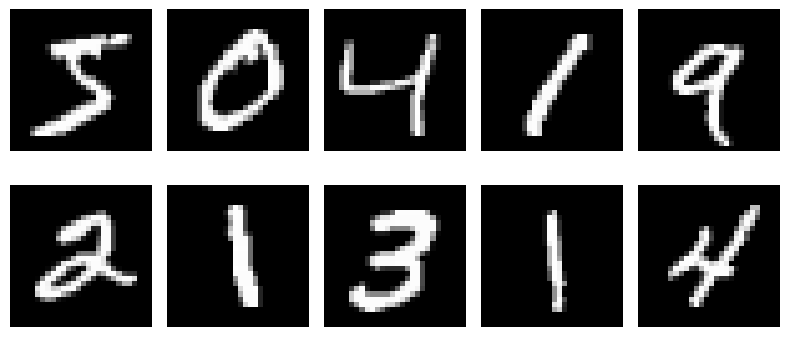

In [4]:
plt.figure(figsize=(8,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
def build_generator():

    model = Sequential()

    model.add(Dense(256, input_dim=100))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dense(28*28, activation='tanh'))
    model.add(Reshape((28,28,1)))

    return model

generator = build_generator()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,486,352 (5.67 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
def build_discriminator():

    model = Sequential()

    model.add(Flatten(input_shape=(28,28,1)))

    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))

    model.add(Dense(1, activation='sigmoid'))

    return model

discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
discriminator.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002, 0.5),
    metrics=['accuracy']
)

In [8]:
discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002, 0.5)
)

In [13]:
epochs = 10000
batch_size = 64
half_batch = batch_size // 2

d_losses = []
g_losses = []

for epoch in range(epochs):

    # -----------------------
    # Train Discriminator
    # -----------------------

    idx = np.random.randint(0, X_train.shape[0], half_batch)
    real_imgs = X_train[idx]

    noise = np.random.normal(0,1,(half_batch,100))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((half_batch,1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((half_batch,1)))

    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)


    # -----------------------
    # Train Generator
    # -----------------------

    noise = np.random.normal(0,1,(batch_size,100))

    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))


    d_losses.append(d_loss[0])
    g_losses.append(g_loss)


    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss[0]:.4f} | G Loss: {g_loss:.4f}")

Epoch 0 | D Loss: 5.8592 | G Loss: 0.0017
Epoch 1000 | D Loss: 6.2788 | G Loss: 0.0010
Epoch 2000 | D Loss: 6.5606 | G Loss: 0.0007
Epoch 3000 | D Loss: 6.7782 | G Loss: 0.0006
Epoch 4000 | D Loss: 6.9583 | G Loss: 0.0005
Epoch 5000 | D Loss: 7.1137 | G Loss: 0.0004
Epoch 6000 | D Loss: 7.2512 | G Loss: 0.0003
Epoch 7000 | D Loss: 7.3749 | G Loss: 0.0003
Epoch 8000 | D Loss: 7.4871 | G Loss: 0.0003
Epoch 9000 | D Loss: 7.5896 | G Loss: 0.0002


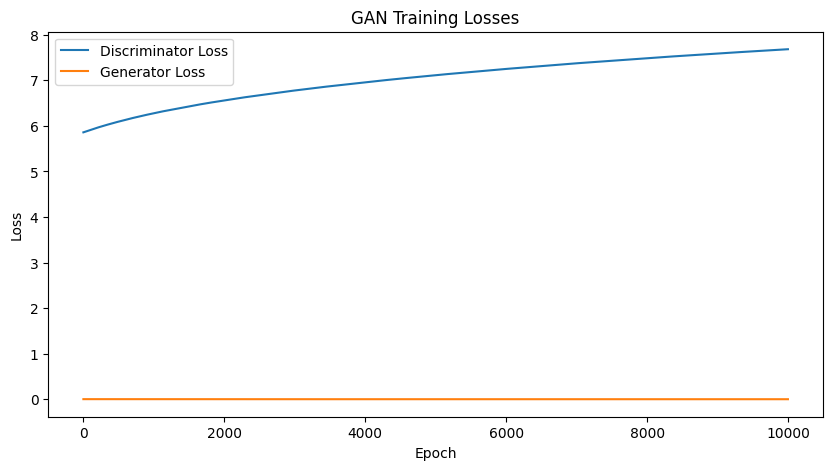

In [14]:
plt.figure(figsize=(10,5))

plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')

plt.title("GAN Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


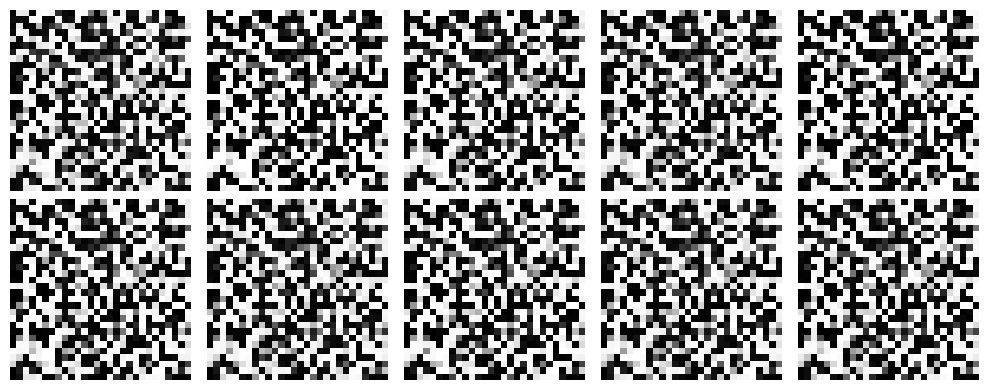

In [15]:
noise = np.random.normal(0,1,(10,100))
generated_images = generator.predict(noise)

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    img = generated_images[i].reshape(28,28)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Result Analysis

- Initially generated images look noisy.
- After training, digit-like shapes appear.
- Loss curves oscillate (normal in GANs).
- Unlike standard neural networks, GAN loss need not monotonically decrease.